Dataset shape: (2000, 21)

First 5 rows:
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15  

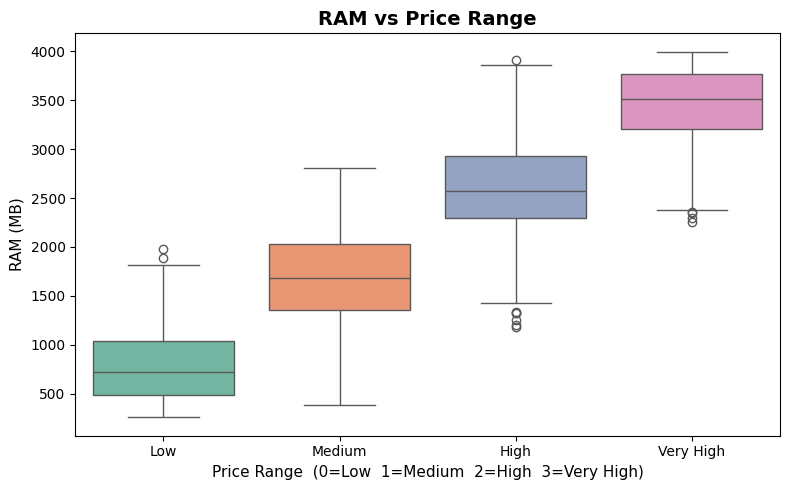

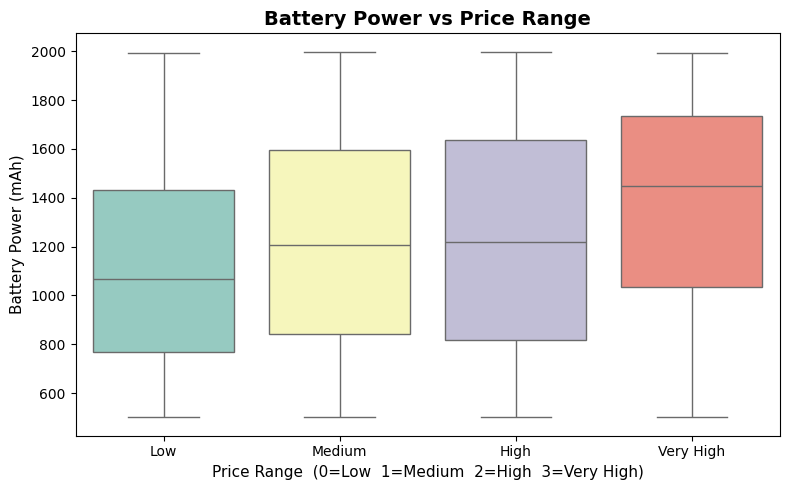


Features shape: (2000, 4)
Target distribution:
 price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

Training samples : 1600
Testing  samples : 400

Model trained successfully.
Tree depth: 5
Number of leaves: 29

Model Accuracy: 82.25%


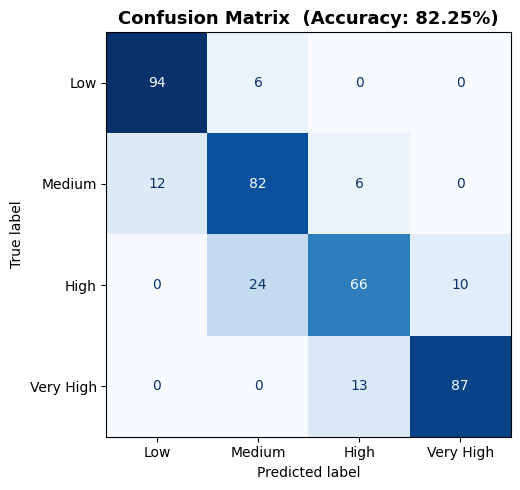

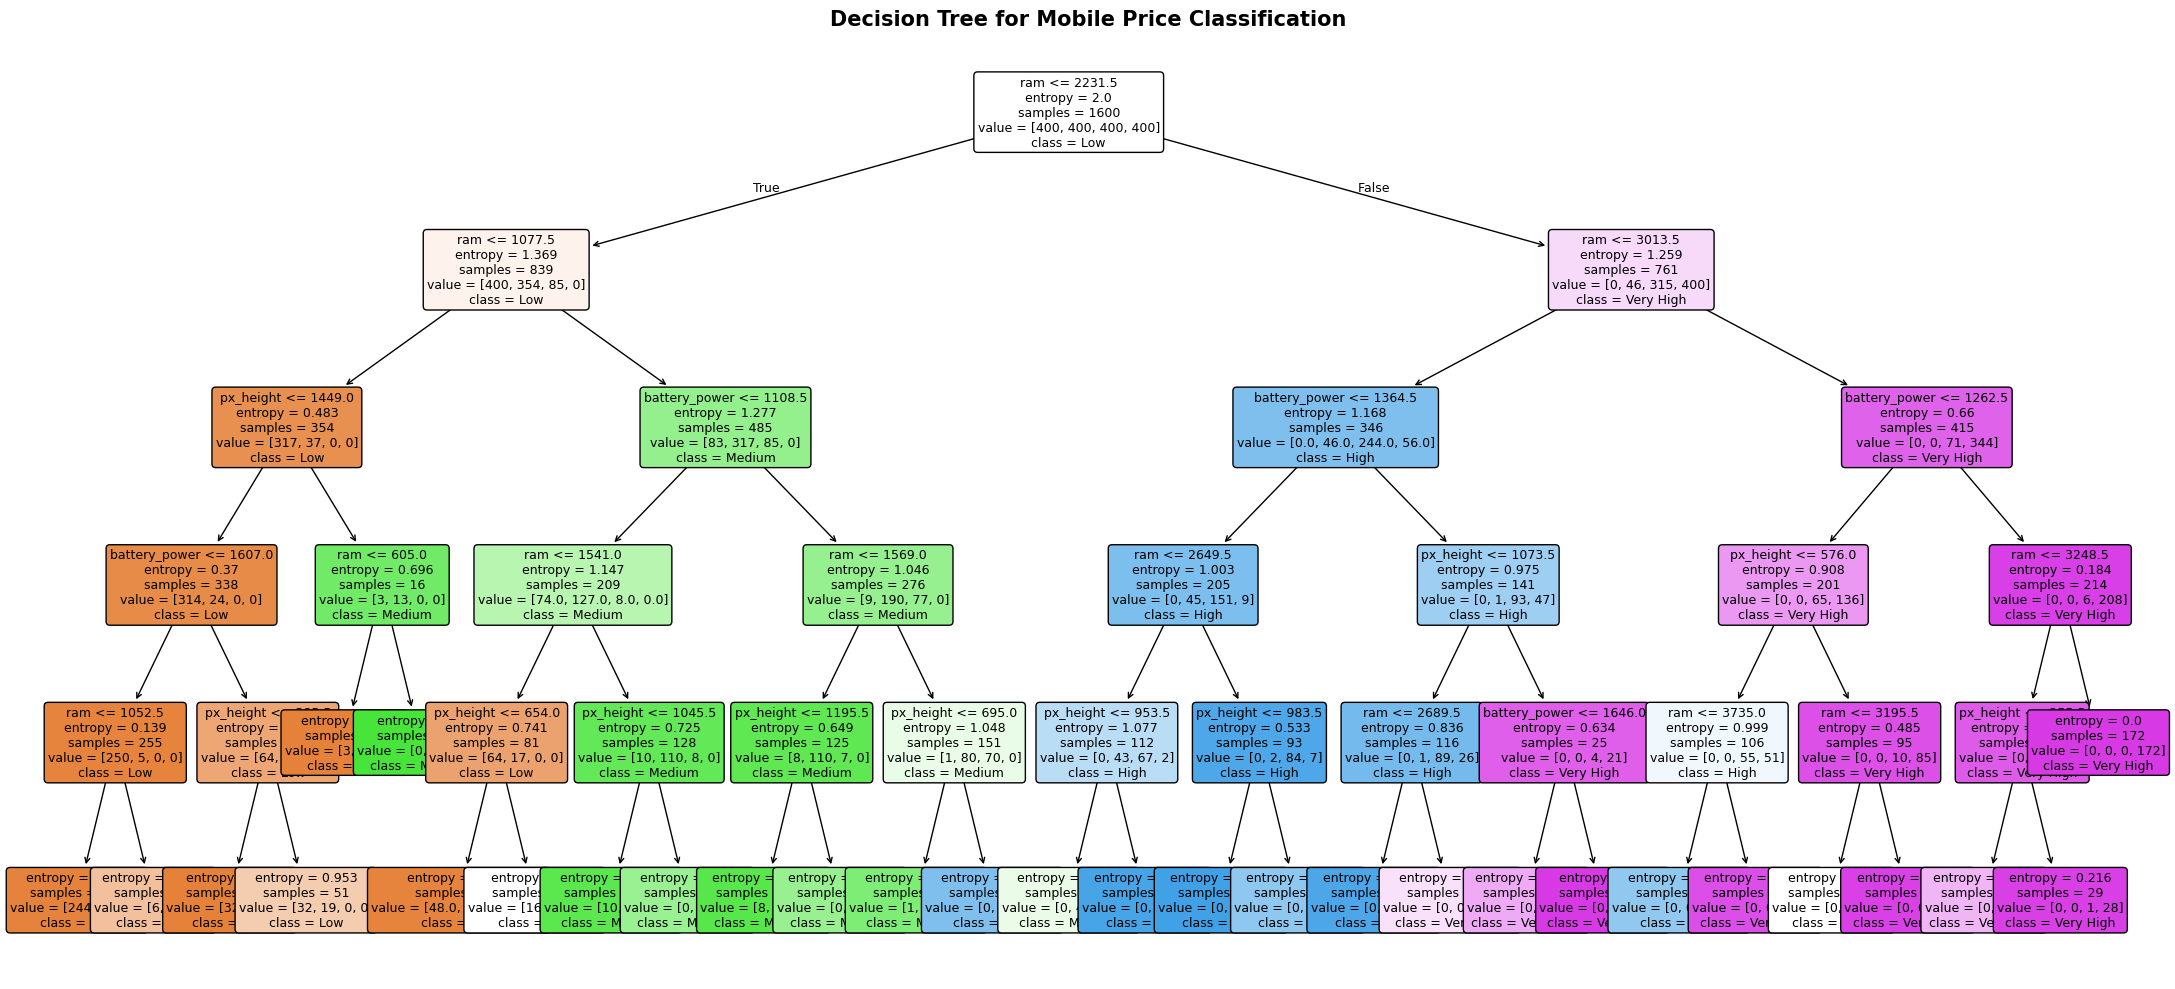


DECISION TREE RULES (text format)
|--- ram <= 2231.50
|   |--- ram <= 1077.50
|   |   |--- px_height <= 1449.00
|   |   |   |--- battery_power <= 1607.00
|   |   |   |   |--- ram <= 1052.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- ram >  1052.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- battery_power >  1607.00
|   |   |   |   |--- px_height <= 385.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- px_height >  385.50
|   |   |   |   |   |--- class: 0
|   |   |--- px_height >  1449.00
|   |   |   |--- ram <= 605.00
|   |   |   |   |--- class: 0
|   |   |   |--- ram >  605.00
|   |   |   |   |--- class: 1
|   |--- ram >  1077.50
|   |   |--- battery_power <= 1108.50
|   |   |   |--- ram <= 1541.00
|   |   |   |   |--- px_height <= 654.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- px_height >  654.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- ram >  1541.00
|   |   |   |   |--- px_height <= 1045.50
|   |   |   |   |   |--- class: 1
|   |

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ── 2. Load the dataset ──────────────────────────────────────

df = pd.read_csv("/content/train.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df[["battery_power", "ram", "px_height", "int_memory", "price_range"]].describe())

# ── 3. EDA – Boxplot: RAM vs Price Range ─────────────────────
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="price_range",
    y="ram",
    hue="price_range",
    palette="Set2",
    legend=False
)
plt.title("RAM vs Price Range", fontsize=14, fontweight="bold")
plt.xlabel("Price Range  (0=Low  1=Medium  2=High  3=Very High)", fontsize=11)
plt.ylabel("RAM (MB)", fontsize=11)
plt.xticks([0, 1, 2, 3], ["Low", "Medium", "High", "Very High"])
plt.tight_layout()
plt.savefig("boxplot_ram_vs_price.png", dpi=150)
plt.show()

# ── 4. EDA – Boxplot: Battery Power vs Price Range ───────────
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="price_range",
    y="battery_power",
    hue="price_range",
    palette="Set3",
    legend=False
)
plt.title("Battery Power vs Price Range", fontsize=14, fontweight="bold")
plt.xlabel("Price Range  (0=Low  1=Medium  2=High  3=Very High)", fontsize=11)
plt.ylabel("Battery Power (mAh)", fontsize=11)
plt.xticks([0, 1, 2, 3], ["Low", "Medium", "High", "Very High"])
plt.tight_layout()
plt.savefig("boxplot_battery_vs_price.png", dpi=150)
plt.show()

# ── 5. Prepare features and target ───────────────────────────
# Use only the 4 specified features
FEATURES = ["battery_power", "ram", "px_height", "int_memory"]

X = df[FEATURES]
y = df["price_range"]

print("\nFeatures shape:", X.shape)
print("Target distribution:\n", y.value_counts().sort_index())

# ── 6. Train / Test Split (80% train, 20% test) ───────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # keeps class balance in both splits
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

# ── 7. Train the Decision Tree Classifier ────────────────────
model = DecisionTreeClassifier(
    criterion="entropy",    # use information gain
    max_depth=5,            # limit depth so the tree stays readable
    random_state=42
)
model.fit(X_train, y_train)

print("\nModel trained successfully.")
print("Tree depth:", model.get_depth())
print("Number of leaves:", model.get_n_leaves())

# ── 8. Evaluate the model ────────────────────────────────────
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Low", "Medium", "High", "Very High"]

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", ax=plt.gca(), colorbar=False)
plt.title(f"Confusion Matrix  (Accuracy: {accuracy*100:.2f}%)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ── 9. Visualize the Decision Tree ───────────────────────────
plt.figure(figsize=(22, 10))
plot_tree(
    model,
    feature_names=FEATURES,
    class_names=labels,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree for Mobile Price Classification", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 10. Print decision rules in text format ──────────────────
print("\n" + "="*60)
print("DECISION TREE RULES (text format)")
print("="*60)
rules = export_text(model, feature_names=FEATURES)
print(rules)

# ── 11. Predict for a new mobile ─────────────────────────────
# New phone specs
new_mobile = pd.DataFrame({
    "battery_power": [3000],
    "ram":           [4000],
    "px_height":     [800],
    "int_memory":    [64]
})

# Get prediction and probability
predicted_class = model.predict(new_mobile)[0]
predicted_proba = model.predict_proba(new_mobile)[0]

# Map class number to readable label
price_labels = {0: "Low", 1: "Medium", 2: "High", 3: "Very High"}

print("\n" + "="*60)
print("PREDICTION FOR NEW MOBILE")
print("="*60)
print(f"  battery_power : 3000 mAh")
print(f"  ram           : 4000 MB")
print(f"  px_height     : 800 px")
print(f"  int_memory    : 64 GB")
print("-"*60)
print(f"  Predicted Price Range : {predicted_class} → {price_labels[predicted_class]}")
print("-"*60)
print("  Class Probabilities:")
for i, prob in enumerate(predicted_proba):
    print(f"    {price_labels[i]:<12} : {prob*100:.1f}%")
print("="*60)


## 12. Feature Importance Visualization

To understand which features contributed most to the model's predictions, we can visualize the feature importances calculated by the Decision Tree Classifier.

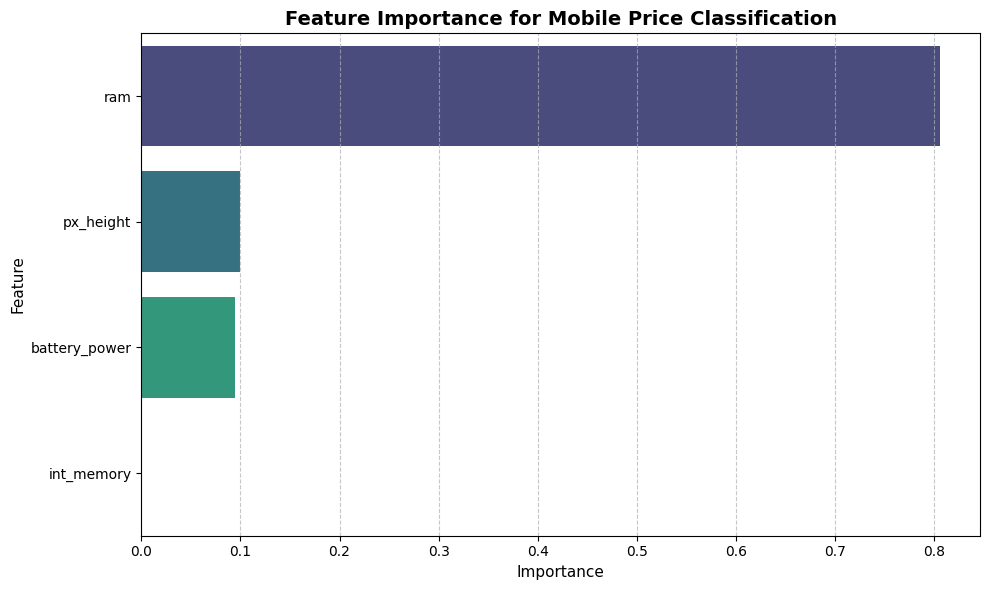

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
importances = model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance for Mobile Price Classification', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 13. Predictions on New Test Data (`test.csv`)

Now, let's load the separate `test.csv` dataset and use our trained Decision Tree model to predict the price ranges for these new mobile phones.

In [5]:
# Load the new test dataset
df_test = pd.read_csv('/content/test.csv')

print('Shape of new test data:', df_test.shape)
print('\nFirst 5 rows of new test data:')
display(df_test.head())

# Prepare features from the new test data using the same FEATURES list
X_new_test = df_test[FEATURES]

print('\nShape of features for new test data:', X_new_test.shape)

Shape of new test data: (1000, 21)

First 5 rows of new test data:


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1



Shape of features for new test data: (1000, 4)


In [6]:
# Make predictions on the new test data
new_test_predictions = model.predict(X_new_test)

# Add predictions to the test DataFrame for easier viewing
df_test['predicted_price_range'] = new_test_predictions

# Map numerical predictions to readable labels
price_labels = {0: 'Low', 1: 'Medium', 2: 'High', 3: 'Very High'}
df_test['predicted_price_range_label'] = df_test['predicted_price_range'].map(price_labels)

print('\nPredictions for the new test data (first 10 rows):')
display(df_test[['id'] + FEATURES + ['predicted_price_range', 'predicted_price_range_label']].head(10))


Predictions for the new test data (first 10 rows):


,id,battery_power,ram,px_height,int_memory,predicted_price_range,predicted_price_range_label
0,1,1043,3476,226,5,2,High
1,2,841,3895,746,61,3,Very High
2,3,1807,2396,1270,27,3,Very High
3,4,1546,3893,295,25,3,Very High
4,5,1434,1773,749,49,2,High
5,6,1464,3506,569,50,3,Very High
6,7,1718,3873,1283,47,3,Very High
7,8,833,1495,1312,62,0,Low
8,9,1111,3485,556,25,2,High
9,10,1520,651,52,25,0,Low
